# Force Range Method — Visual Explanation

This notebook walks through, step by step, how the force range on each pipe segment
is computed from wave and current velocities. The key insight is that the **strain range**
(which drives fatigue) comes from the **vector difference** of crest and trough forces,
not from subtracting unsigned magnitudes.

**Steps:**
1. Wave velocity vector (oscillates: crest vs trough)
2. Current velocity vector (steady)
3. Decomposition into normal/parallel components relative to a pipe segment
4. Drag forces for crest and trough states
5. Force range vector: F_crest - F_trough
6. Beam moments from the range forces

In [90]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

script_dir = os.path.dirname(os.path.abspath('__file__'))
# If running from the notebook's directory:
script_dir = os.path.abspath('.')
sys.path.insert(0, script_dir)

from fls_proxy_ff import build_segments_3d, fixed_fixed_beam, moment_at, get_curvature_from_moment

# constants
CPS_HEADING = 0
RHO = 1025
CD = 1.2
D = 0.251
R_OUTER = D / 2.0

def dir_vec(heading_deg):
    rad = np.radians(heading_deg)
    return np.array([np.sin(rad), np.cos(rad), 0.0])

# load geometry
seg_df = pd.read_excel(os.path.join(script_dir, 'segments.xlsx'))
segments, bellmouth, touchdown = build_segments_3d(seg_df, CPS_HEADING)
beam_vec = touchdown - bellmouth
L_beam = np.linalg.norm(beam_vec)
beam_axis = beam_vec / L_beam

# pick one segment for the detailed walkthrough (middle segment)
seg = segments[len(segments) // 2]
print(f'Using segment: {seg["seg_id"]}')
print(f'Segment axis: {np.round(seg["axis"], 3)}')
print(f'Segment midpoint: {np.round(seg["midpoint"], 2)}')
print(f'Beam axis: {np.round(beam_axis, 3)}')

Using segment: seg_3
Segment axis: [0.    1.    0.022]
Segment midpoint: [ 0.   18.    0.13]
Beam axis: [ 0.     0.994 -0.105]


In [91]:
# define test conditions
wave_dir = 30   # degrees
curr_dir = 150  # degrees (perpendicular to wave)
u_w = 0.2      # wave particle velocity [m/s]
Uc = 0.05       # current magnitude [m/s]

wave_dir_vec = dir_vec(wave_dir)
curr_vec = Uc * dir_vec(curr_dir)

print(f'Wave direction: {wave_dir} deg -> vector: {np.round(wave_dir_vec, 3)}')
print(f'Current direction: {curr_dir} deg, Uc={Uc} m/s -> vector: {np.round(curr_vec, 3)}')
print(f'u_w = {u_w} m/s')

Wave direction: 30 deg -> vector: [0.5   0.866 0.   ]
Current direction: 150 deg, Uc=0.05 m/s -> vector: [ 0.025 -0.043  0.   ]
u_w = 0.2 m/s


## Step 1 — Wave and Current Velocity Vectors

The wave velocity oscillates between **+u_w** (crest) and **-u_w** (trough).
The current is steady — same magnitude and direction at all times.

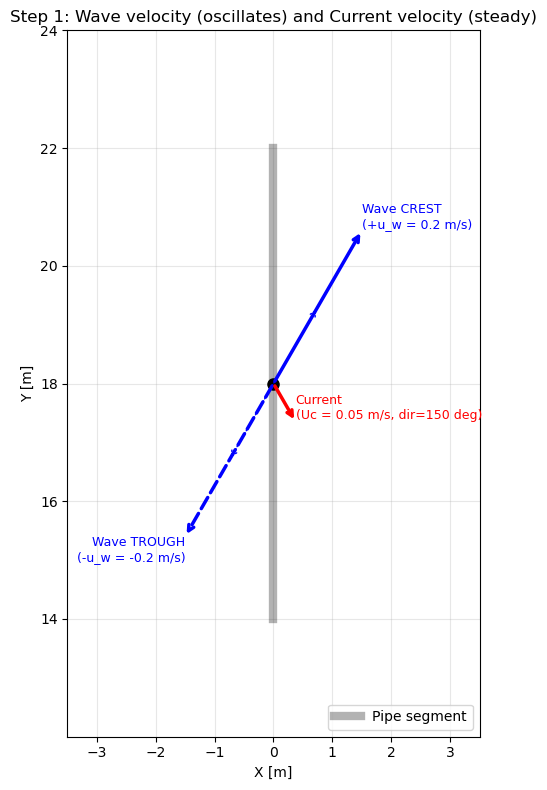

In [92]:
fig, ax = plt.subplots(figsize=(8, 8))
origin = seg['midpoint'][:2]

# wave crest velocity
V_wave_crest = u_w * wave_dir_vec[:2]
V_wave_trough = -u_w * wave_dir_vec[:2]

# current velocity
V_curr = curr_vec[:2]

# segment axis (projected to 2D)
seg_ax_2d = seg['axis'][:2]
seg_ax_2d_norm = seg_ax_2d / np.linalg.norm(seg_ax_2d) if np.linalg.norm(seg_ax_2d) > 0 else seg_ax_2d

# draw pipe segment
pipe_len = 4.0
p1 = origin - pipe_len * seg_ax_2d_norm
p2 = origin + pipe_len * seg_ax_2d_norm
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', linewidth=6, alpha=0.3, label='Pipe segment')

# scale arrows for visibility
scale = 15.0

# collect all key points for axis limits
key_points = [origin, p1, p2,
              origin + V_wave_crest * scale,
              origin + V_wave_trough * scale,
              origin + V_curr * scale]
all_xy = np.array(key_points)
pad = 2.0
ax.set_xlim(all_xy[:, 0].min() - pad, all_xy[:, 0].max() + pad)
ax.set_ylim(all_xy[:, 1].min() - pad, all_xy[:, 1].max() + pad)

# wave crest (blue, solid)
ax.annotate('', xy=origin + V_wave_crest * scale, xytext=origin,
            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.annotate(f'Wave CREST\n(+u_w = {u_w} m/s)',
            xy=origin + V_wave_crest * scale, fontsize=9, color='blue',
            ha='left', va='bottom')

# wave trough (blue, dashed)
ax.annotate('', xy=origin + V_wave_trough * scale, xytext=origin,
            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5, linestyle='dashed'))
ax.annotate(f'Wave TROUGH\n(-u_w = {-u_w} m/s)',
            xy=origin + V_wave_trough * scale, fontsize=9, color='blue',
            ha='right', va='top')

# current (red)
ax.annotate('', xy=origin + V_curr * scale, xytext=origin,
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax.annotate(f'Current\n(Uc = {Uc} m/s, dir={curr_dir} deg)',
            xy=origin + V_curr * scale, fontsize=9, color='red',
            ha='left', va='bottom')

# double arrow for wave oscillation
ax.annotate('', xy=origin + V_wave_crest * scale * 0.5,
            xytext=origin + V_wave_trough * scale * 0.5,
            arrowprops=dict(arrowstyle='<->', color='blue', lw=1, linestyle='dotted'))

ax.plot(*origin, 'ko', markersize=8)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_title('Step 1: Wave velocity (oscillates) and Current velocity (steady)', fontsize=12)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 2 — Total Velocity and Decomposition

For each state (crest/trough), the total velocity is **V = wave + current**.
We then decompose into:
- **V_parallel**: along the segment axis (does NOT create drag)
- **V_normal**: perpendicular to the segment axis (creates cross-flow drag)

In [93]:
def decompose(V_total, seg_axis):
    V_par = np.dot(V_total, seg_axis) * seg_axis
    V_norm = V_total - V_par
    return V_par, V_norm

# crest
V_crest = u_w * wave_dir_vec + curr_vec
V_par_c, V_norm_c = decompose(V_crest, seg['axis'])

# trough
V_trough = -u_w * wave_dir_vec + curr_vec
V_par_t, V_norm_t = decompose(V_trough, seg['axis'])

print(f'CREST:  V_total = {np.round(V_crest, 4)}')
print(f'        V_par   = {np.round(V_par_c, 4)}  (|V_par| = {np.linalg.norm(V_par_c):.4f})')
print(f'        V_norm  = {np.round(V_norm_c, 4)}  (|V_norm| = {np.linalg.norm(V_norm_c):.4f})')
print()
print(f'TROUGH: V_total = {np.round(V_trough, 4)}')
print(f'        V_par   = {np.round(V_par_t, 4)}  (|V_par| = {np.linalg.norm(V_par_t):.4f})')
print(f'        V_norm  = {np.round(V_norm_t, 4)}  (|V_norm| = {np.linalg.norm(V_norm_t):.4f})')

CREST:  V_total = [0.125  0.1299 0.    ]
        V_par   = [0.     0.1298 0.0029]  (|V_par| = 0.1299)
        V_norm  = [ 1.25e-01  1.00e-04 -2.90e-03]  (|V_norm| = 0.1250)

TROUGH: V_total = [-0.075  -0.2165  0.    ]
        V_par   = [-0.     -0.2164 -0.0048]  (|V_par| = 0.2165)
        V_norm  = [-0.075  -0.0001  0.0048]  (|V_norm| = 0.0752)


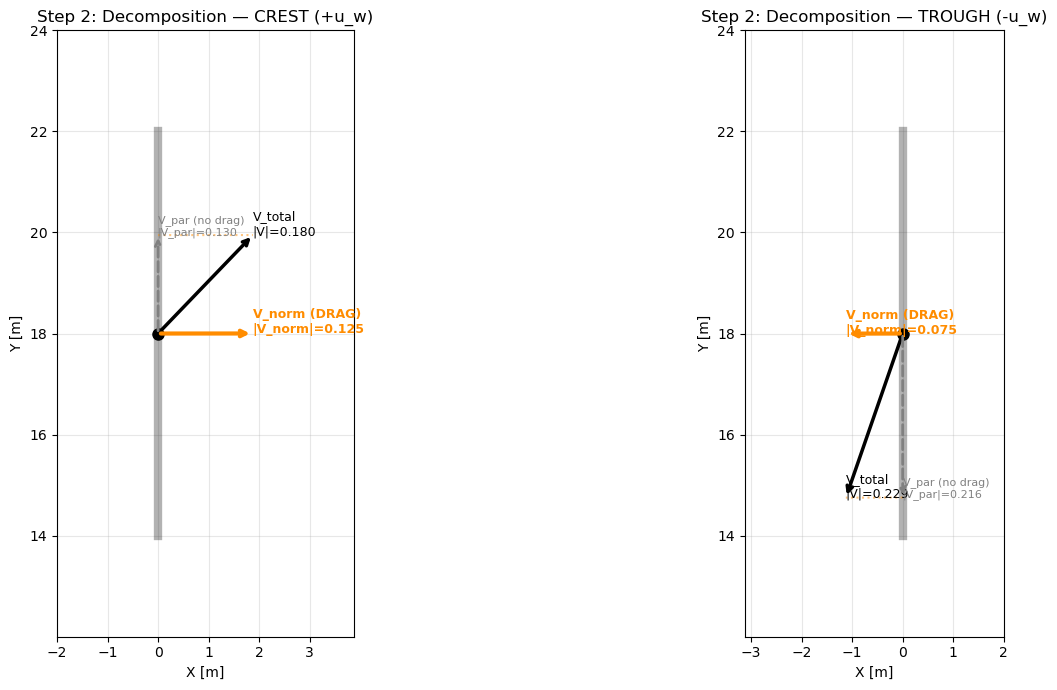

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
scale = 15.0

for ax, (state_name, V_total, V_par, V_norm) in zip(axes, [
    ('CREST (+u_w)', V_crest, V_par_c, V_norm_c),
    ('TROUGH (-u_w)', V_trough, V_par_t, V_norm_t),
]):
    o = origin.copy()

    # pipe segment
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', linewidth=6, alpha=0.3)

    # set axis limits from all arrow tips
    key_points = [o, p1, p2,
                  o + V_total[:2] * scale,
                  o + V_par[:2] * scale,
                  o + V_norm[:2] * scale]
    all_xy = np.array(key_points)
    pad = 2.0
    ax.set_xlim(all_xy[:, 0].min() - pad, all_xy[:, 0].max() + pad)
    ax.set_ylim(all_xy[:, 1].min() - pad, all_xy[:, 1].max() + pad)

    # total velocity
    ax.annotate('', xy=o + V_total[:2] * scale, xytext=o,
                arrowprops=dict(arrowstyle='->', color='black', lw=2.5))
    ax.annotate(f'V_total\n|V|={np.linalg.norm(V_total):.3f}',
                xy=o + V_total[:2] * scale, fontsize=9, color='black',
                ha='left')

    # parallel component (grey, along pipe)
    ax.annotate('', xy=o + V_par[:2] * scale, xytext=o,
                arrowprops=dict(arrowstyle='->', color='grey', lw=2, linestyle='dashed'))
    ax.annotate(f'V_par (no drag)\n|V_par|={np.linalg.norm(V_par):.3f}',
                xy=o + V_par[:2] * scale, fontsize=8, color='grey')

    # normal component (orange, creates drag)
    ax.annotate('', xy=o + V_norm[:2] * scale, xytext=o,
                arrowprops=dict(arrowstyle='->', color='darkorange', lw=3))
    ax.annotate(f'V_norm (DRAG)\n|V_norm|={np.linalg.norm(V_norm):.3f}',
                xy=o + V_norm[:2] * scale, fontsize=9, color='darkorange',
                fontweight='bold')

    # show the decomposition triangle
    tip_par = o + V_par[:2] * scale
    tip_total = o + V_total[:2] * scale
    ax.plot([tip_par[0], tip_total[0]], [tip_par[1], tip_total[1]],
            ':', color='darkorange', lw=1.5, alpha=0.5)

    ax.plot(*o, 'ko', markersize=8)
    ax.set_title(f'Step 2: Decomposition — {state_name}', fontsize=12)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')

plt.tight_layout()
plt.show()

## Step 3 — Drag Forces (Crest vs Trough)

The drag force on the segment is:

$$F = \frac{1}{2} \rho C_d D \, |V_n|^2 \, L_{seg} \cdot \hat{V}_n$$

Note:
- Force is proportional to **V_n squared** (quadratic drag)
- Force direction follows V_normal
- We then project F onto the plane perpendicular to the **beam axis** (the equivalent beam chord)

In [95]:
def compute_F_perp(V_norm, seg_length, beam_axis):
    V_n = np.linalg.norm(V_norm)
    if V_n > 0:
        F_vec = 0.5 * RHO * CD * D * V_n**2 * seg_length * (V_norm / V_n)
        F_along = np.dot(F_vec, beam_axis) * beam_axis
        F_perp = F_vec - F_along
    else:
        F_perp = np.zeros(3)
    return F_perp

F_perp_crest = compute_F_perp(V_norm_c, seg['length'], beam_axis)
F_perp_trough = compute_F_perp(V_norm_t, seg['length'], beam_axis)

print(f'CREST  F_perp = {np.round(F_perp_crest, 4)}  |F| = {np.linalg.norm(F_perp_crest):.4f} N')
print(f'TROUGH F_perp = {np.round(F_perp_trough, 4)}  |F| = {np.linalg.norm(F_perp_trough):.4f} N')
print()
print(f'Ratio |F_crest|/|F_trough| = {np.linalg.norm(F_perp_crest)/max(np.linalg.norm(F_perp_trough),1e-12):.2f}')

CREST  F_perp = [17.3749 -0.0413 -0.391 ]  |F| = 17.3794 N
TROUGH F_perp = [-6.2659  0.0414  0.3917]  |F| = 6.2783 N

Ratio |F_crest|/|F_trough| = 2.77


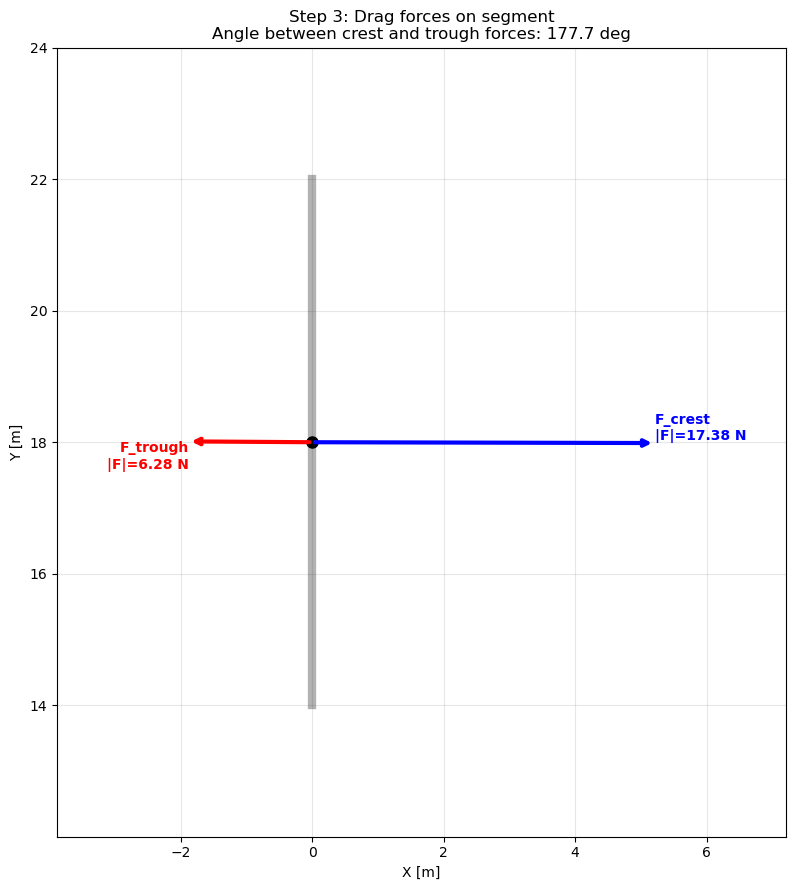

In [96]:
fig, ax = plt.subplots(figsize=(9, 9))
o = origin.copy()
scale_f = 0.3  # scale for force arrows (forces are in Newtons, much larger)

# pipe
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', linewidth=6, alpha=0.3, label='Pipe segment')

# crest force (blue)
Fc_2d = F_perp_crest[:2] * scale_f
# trough force (red)
Ft_2d = F_perp_trough[:2] * scale_f

# set axis limits from all arrow tips
key_points = [o, p1, p2, o + Fc_2d, o + Ft_2d]
all_xy = np.array(key_points)
pad = 2.0
ax.set_xlim(all_xy[:, 0].min() - pad, all_xy[:, 0].max() + pad)
ax.set_ylim(all_xy[:, 1].min() - pad, all_xy[:, 1].max() + pad)

ax.annotate('', xy=o + Fc_2d, xytext=o,
            arrowprops=dict(arrowstyle='->', color='blue', lw=3))
ax.annotate(f'F_crest\n|F|={np.linalg.norm(F_perp_crest):.2f} N',
            xy=o + Fc_2d, fontsize=10, color='blue', fontweight='bold',
            ha='left', va='bottom')

ax.annotate('', xy=o + Ft_2d, xytext=o,
            arrowprops=dict(arrowstyle='->', color='red', lw=3))
ax.annotate(f'F_trough\n|F|={np.linalg.norm(F_perp_trough):.2f} N',
            xy=o + Ft_2d, fontsize=10, color='red', fontweight='bold',
            ha='right', va='top')

# angle between them
cos_angle = np.dot(F_perp_crest, F_perp_trough) / (
    np.linalg.norm(F_perp_crest) * max(np.linalg.norm(F_perp_trough), 1e-12))
angle_deg = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
ax.set_title(f'Step 3: Drag forces on segment\n'
             f'Angle between crest and trough forces: {angle_deg:.1f} deg',
             fontsize=12)

ax.plot(*o, 'ko', markersize=8)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
plt.tight_layout()
plt.show()

## Step 4 — The Force Range Vector

The force **range** is the vector difference:

$$\vec{F}_{range} = \vec{F}_{crest} - \vec{F}_{trough}$$

This captures:
- If forces point in **opposite** directions (wave dominates): range ~ F_crest + F_trough
- If forces point in the **same** direction (current dominates): range ~ |F_crest - F_trough|
- The **non-collinear** case is handled correctly through vector subtraction

The plot below shows this graphically using the parallelogram rule.

In [97]:
F_range = F_perp_crest - F_perp_trough

print(f'F_crest  = {np.round(F_perp_crest, 4)}')
print(f'F_trough = {np.round(F_perp_trough, 4)}')
print(f'F_range  = F_crest - F_trough = {np.round(F_range, 4)}')
print(f'|F_range| = {np.linalg.norm(F_range):.4f} N')
print()
print(f'Compare with unsigned difference: ||F_crest| - |F_trough|| = '
      f'{abs(np.linalg.norm(F_perp_crest) - np.linalg.norm(F_perp_trough)):.4f} N')
print(f'Compare with sum: |F_crest| + |F_trough| = '
      f'{np.linalg.norm(F_perp_crest) + np.linalg.norm(F_perp_trough):.4f} N')

F_crest  = [17.3749 -0.0413 -0.391 ]
F_trough = [-6.2659  0.0414  0.3917]
F_range  = F_crest - F_trough = [23.6408 -0.0827 -0.7827]
|F_range| = 23.6539 N

Compare with unsigned difference: ||F_crest| - |F_trough|| = 11.1011 N
Compare with sum: |F_crest| + |F_trough| = 23.6576 N


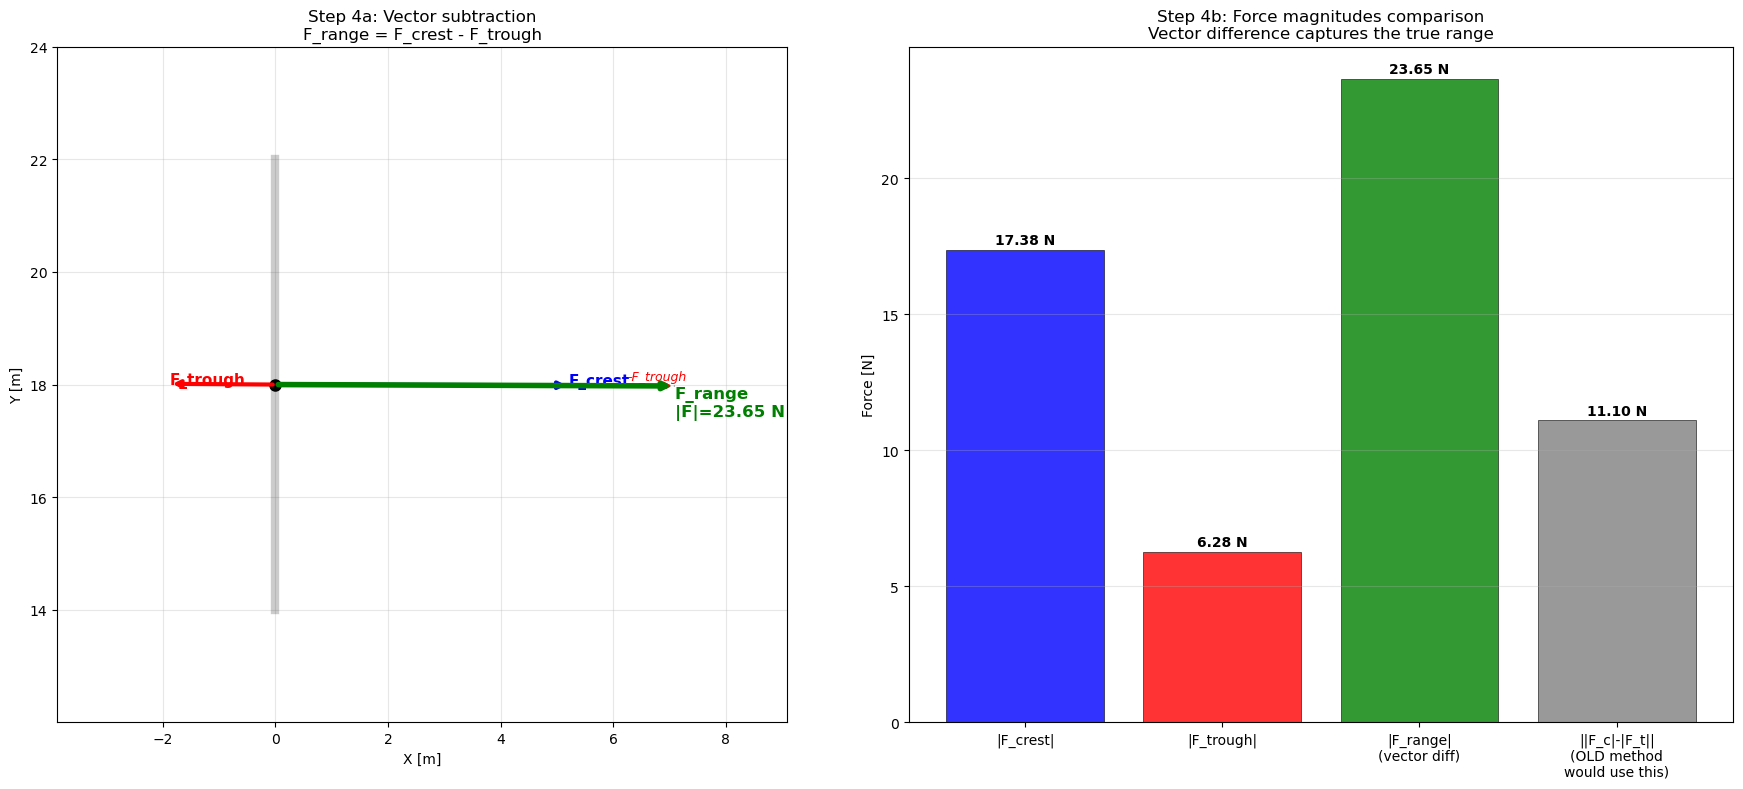

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
o = origin.copy()

# --- Left: vector subtraction diagram ---
ax = axes[0]
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', linewidth=6, alpha=0.2)

Fc = F_perp_crest[:2] * scale_f
Ft = F_perp_trough[:2] * scale_f
Fr = F_range[:2] * scale_f

# set axis limits from all arrow tips
key_points = [o, p1, p2, o + Fc, o + Ft, o + Fr, o + Fc - Ft]
all_xy = np.array(key_points)
pad = 2.0
ax.set_xlim(all_xy[:, 0].min() - pad, all_xy[:, 0].max() + pad)
ax.set_ylim(all_xy[:, 1].min() - pad, all_xy[:, 1].max() + pad)

# F_crest (blue)
ax.annotate('', xy=o + Fc, xytext=o,
            arrowprops=dict(arrowstyle='->', color='blue', lw=3))
ax.annotate('F_crest', xy=o + Fc, fontsize=11, color='blue', fontweight='bold')

# F_trough (red)
ax.annotate('', xy=o + Ft, xytext=o,
            arrowprops=dict(arrowstyle='->', color='red', lw=3))
ax.annotate('F_trough', xy=o + Ft, fontsize=11, color='red', fontweight='bold')

# -F_trough (red dashed, from tip of F_crest)
ax.annotate('', xy=o + Fc - Ft, xytext=o + Fc,
            arrowprops=dict(arrowstyle='->', color='red', lw=2, linestyle='dashed'))
ax.annotate('-F_trough', xy=o + Fc - Ft * 0.5 + np.array([0.1, 0.1]),
            fontsize=9, color='red', style='italic')

# F_range = F_crest + (-F_trough) (green, thick)
ax.annotate('', xy=o + Fr, xytext=o,
            arrowprops=dict(arrowstyle='->', color='green', lw=4))
ax.annotate(f'F_range\n|F|={np.linalg.norm(F_range):.2f} N',
            xy=o + Fr, fontsize=12, color='green', fontweight='bold',
            ha='left', va='top')

# dashed line completing the parallelogram
ax.plot([o[0] + Fc[0], o[0] + Fr[0]], [o[1] + Fc[1], o[1] + Fr[1]],
        ':', color='grey', lw=1.5, alpha=0.7)

ax.plot(*o, 'ko', markersize=8)
ax.set_title('Step 4a: Vector subtraction\nF_range = F_crest - F_trough', fontsize=12)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')

# --- Right: comparison bar chart ---
ax = axes[1]
labels = ['|F_crest|', '|F_trough|', '|F_range|\n(vector diff)',
          '||F_c|-|F_t||\n(OLD method\nwould use this)']
values = [
    np.linalg.norm(F_perp_crest),
    np.linalg.norm(F_perp_trough),
    np.linalg.norm(F_range),
    abs(np.linalg.norm(F_perp_crest) - np.linalg.norm(F_perp_trough)),
]
colors = ['blue', 'red', 'green', 'grey']
bars = ax.bar(labels, values, color=colors, edgecolor='k', linewidth=0.5, alpha=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f} N', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Force [N]')
ax.set_title('Step 4b: Force magnitudes comparison\n'
             'Vector difference captures the true range', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5 — All Segments: Force Vectors on the Catenary

Now apply the same procedure to all segments and visualise in 3D.

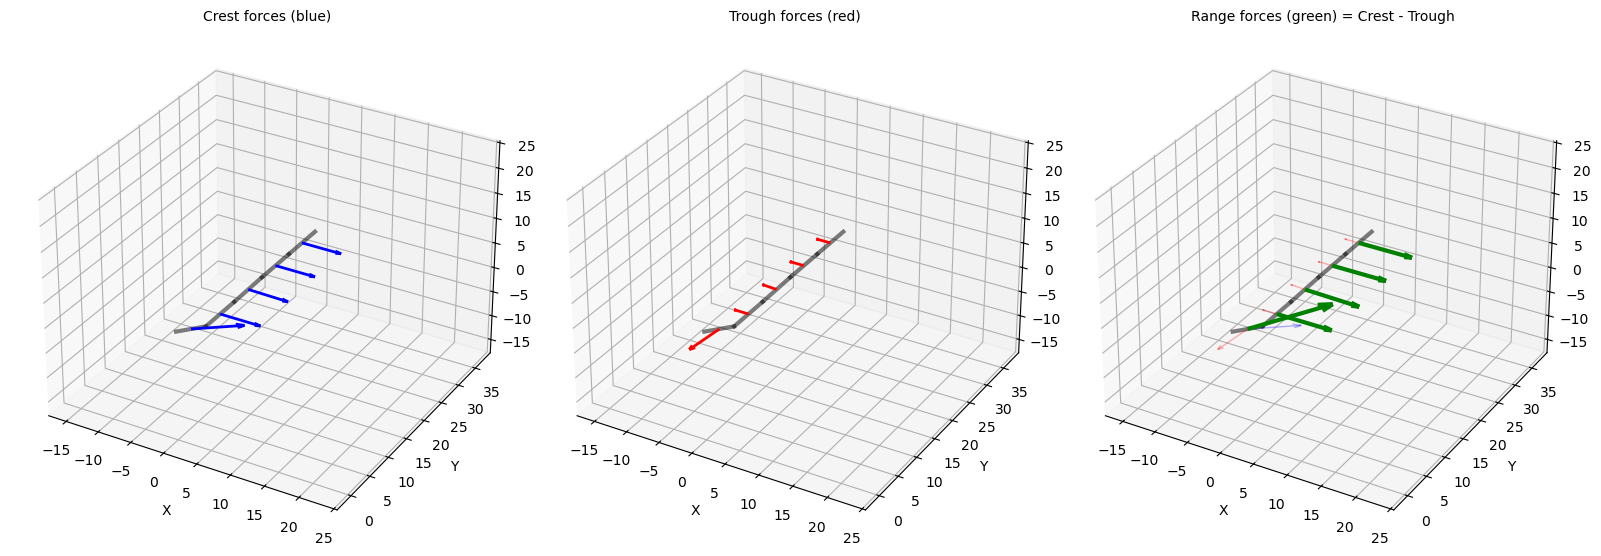

In [99]:
fig = plt.figure(figsize=(16, 6))

titles = ['Crest forces (blue)', 'Trough forces (red)',
          'Range forces (green) = Crest - Trough']

for panel_idx in range(3):
    ax = fig.add_subplot(1, 3, panel_idx + 1, projection='3d')

    # draw pipe
    for s in segments:
        ax.plot([s['start'][0], s['end'][0]],
                [s['start'][1], s['end'][1]],
                [s['start'][2], s['end'][2]], 'k-', linewidth=3, alpha=0.5)

    # compute forces for all segments
    all_mags = []
    seg_data = []
    for s in segments:
        Vc = u_w * wave_dir_vec + curr_vec
        Vt = -u_w * wave_dir_vec + curr_vec
        _, Vn_c = decompose(Vc, s['axis'])
        _, Vn_t = decompose(Vt, s['axis'])
        Fc = compute_F_perp(Vn_c, s['length'], beam_axis)
        Ft = compute_F_perp(Vn_t, s['length'], beam_axis)
        Fr = Fc - Ft
        seg_data.append((s['midpoint'], Fc, Ft, Fr))
        all_mags.extend([np.linalg.norm(Fc), np.linalg.norm(Ft), np.linalg.norm(Fr)])

    max_mag = max(all_mags) if max(all_mags) > 0 else 1.0
    arrow_scale = 15.0 / max_mag

    for mid, Fc, Ft, Fr in seg_data:
        if panel_idx == 0:  # crest
            ax.quiver(*mid, *(Fc * arrow_scale), color='blue', lw=2, arrow_length_ratio=0.15)
        elif panel_idx == 1:  # trough
            ax.quiver(*mid, *(Ft * arrow_scale), color='red', lw=2, arrow_length_ratio=0.15)
        else:  # range
            # show crest and trough faintly
            ax.quiver(*mid, *(Fc * arrow_scale), color='blue', lw=1, alpha=0.3,
                      arrow_length_ratio=0.15)
            ax.quiver(*mid, *(Ft * arrow_scale), color='red', lw=1, alpha=0.3,
                      arrow_length_ratio=0.15)
            # range in bold green
            ax.quiver(*mid, *(Fr * arrow_scale), color='green', lw=3, arrow_length_ratio=0.15)

    # collect bounding box from pipe + arrow tips for equal axis scaling
    all_pts = []
    for s in segments:
        all_pts.append(s['start'])
        all_pts.append(s['end'])
    for mid, Fc, Ft, Fr in seg_data:
        for F in [Fc, Ft, Fr]:
            all_pts.append(mid + F * arrow_scale)
    all_pts = np.array(all_pts)
    mins = all_pts.min(axis=0)
    maxs = all_pts.max(axis=0)
    centers = (mins + maxs) / 2
    half_range = max((maxs - mins).max() / 2, 1.0)
    pad = 1.2
    ax.set_xlim(centers[0] - half_range * pad, centers[0] + half_range * pad)
    ax.set_ylim(centers[1] - half_range * pad, centers[1] + half_range * pad)
    ax.set_zlim(centers[2] - half_range * pad, centers[2] + half_range * pad)

    ax.set_title(titles[panel_idx], fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.tight_layout()
plt.show()

## Step 6 — Beam Moments from Range Forces

The `|F_range|` for each segment becomes the load on the 1D fixed-fixed beam.
The resulting moments **are** the moment range — one solve instead of two.

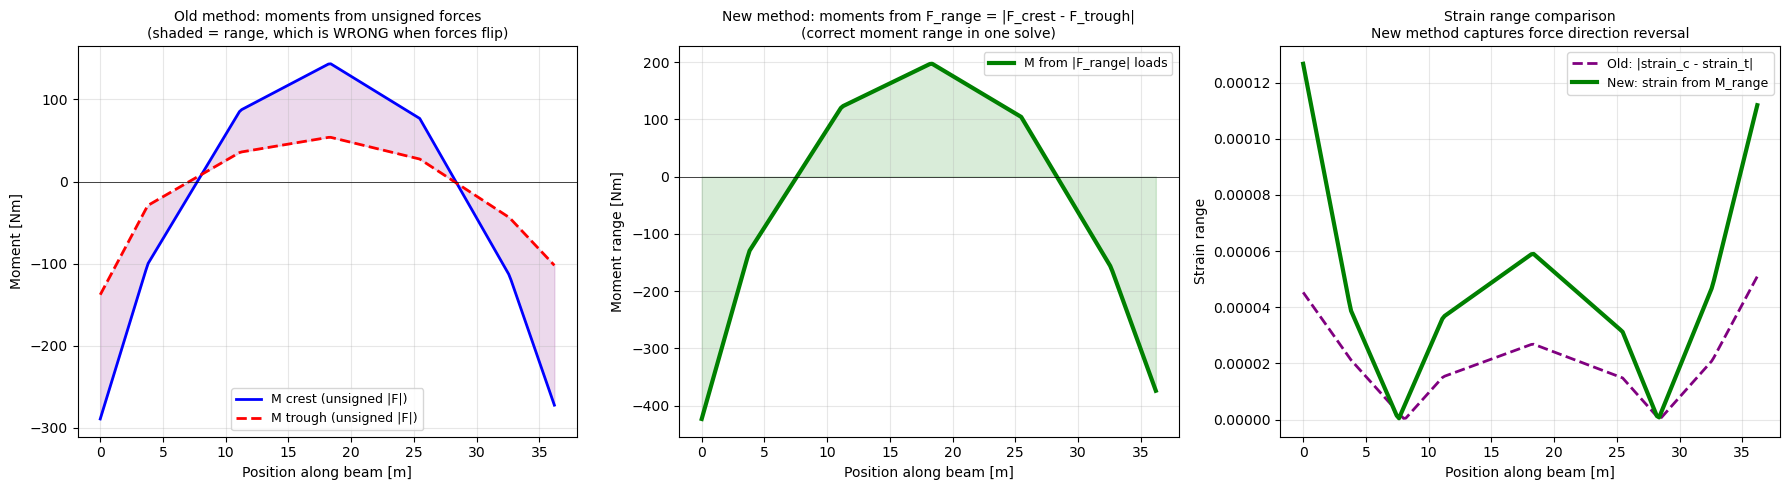

Old max strain range: 5.098076e-05
New max strain range: 1.267189e-04
Ratio new/old: 2.49x


In [100]:
# compute range loads for all segments
range_loads = []
crest_loads = []
trough_loads = []

for s in segments:
    Vc = u_w * wave_dir_vec + curr_vec
    Vt = -u_w * wave_dir_vec + curr_vec
    _, Vn_c = decompose(Vc, s['axis'])
    _, Vn_t = decompose(Vt, s['axis'])
    Fc = compute_F_perp(Vn_c, s['length'], beam_axis)
    Ft = compute_F_perp(Vn_t, s['length'], beam_axis)
    Fr = Fc - Ft

    a_i = np.dot(s['midpoint'] - bellmouth, beam_axis)
    a_i = max(0.0, min(a_i, L_beam))

    range_loads.append((a_i, np.linalg.norm(Fr)))
    crest_loads.append((a_i, np.linalg.norm(Fc)))
    trough_loads.append((a_i, np.linalg.norm(Ft)))

# solve beams
n_pts = 200
x_eval = np.linspace(0, L_beam, n_pts)

def solve_moments(loads):
    M0, ML, R0 = fixed_fixed_beam(loads, L_beam)
    return np.array([moment_at(x, loads, M0, R0) for x in x_eval])

M_crest = solve_moments(crest_loads)
M_trough = solve_moments(trough_loads)
M_range = solve_moments(range_loads)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# crest + trough (old approach: both positive because unsigned loads)
ax = axes[0]
ax.plot(x_eval, M_crest, 'b-', lw=2, label='M crest (unsigned |F|)')
ax.plot(x_eval, M_trough, 'r--', lw=2, label='M trough (unsigned |F|)')
ax.fill_between(x_eval, M_crest, M_trough, alpha=0.15, color='purple')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Old method: moments from unsigned forces\n'
             '(shaded = range, which is WRONG when forces flip)', fontsize=10)
ax.set_xlabel('Position along beam [m]')
ax.set_ylabel('Moment [Nm]')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# range moment (new approach)
ax = axes[1]
ax.plot(x_eval, M_range, 'g-', lw=3, label='M from |F_range| loads')
ax.fill_between(x_eval, 0, M_range, alpha=0.15, color='green')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('New method: moments from F_range = |F_crest - F_trough|\n'
             '(correct moment range in one solve)', fontsize=10)
ax.set_xlabel('Position along beam [m]')
ax.set_ylabel('Moment range [Nm]')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# comparison: strain
ax = axes[2]
strain_c = np.array([get_curvature_from_moment(m) * R_OUTER for m in M_crest])
strain_t = np.array([get_curvature_from_moment(m) * R_OUTER for m in M_trough])
strain_range_old = np.abs(strain_c - strain_t)
strain_range_new = np.array([get_curvature_from_moment(m) * R_OUTER for m in M_range])

ax.plot(x_eval, strain_range_old, 'purple', lw=2, ls='--', label='Old: |strain_c - strain_t|')
ax.plot(x_eval, strain_range_new, 'g-', lw=3, label='New: strain from M_range')
ax.set_title('Strain range comparison\n'
             'New method captures force direction reversal', fontsize=10)
ax.set_xlabel('Position along beam [m]')
ax.set_ylabel('Strain range')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Old max strain range: {np.max(strain_range_old):.6e}')
print(f'New max strain range: {np.max(strain_range_new):.6e}')
print(f'Ratio new/old: {np.max(strain_range_new)/max(np.max(strain_range_old), 1e-20):.2f}x')

## Summary

| Step | What happens | Key point |
|------|-------------|----------|
| 1 | Wave velocity oscillates (+u_w / -u_w), current is steady | Only wave flips between crest and trough |
| 2 | Decompose total velocity into normal/parallel to segment | Only the normal component creates drag |
| 3 | Compute drag force F = 0.5 rho Cd D V_n^2 (quadratic) | Crest and trough forces differ in magnitude AND direction |
| 4 | F_range = F_crest - F_trough (vector subtraction) | Captures direction reversal, non-collinear cases, and magnitude difference |
| 5 | Use |F_range| as beam load, solve once | Moments = moment range directly |

**Why the old method was wrong:** it took |F_perp| (discarding direction), so when forces flipped
between crest and trough, it saw two positive loads of similar magnitude and computed a near-zero range.
The new method preserves the direction through vector subtraction before taking the magnitude.